In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv("../data/raw/train_raw.csv")
df.sample(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
17,18,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
1200,1201,20,RL,71.0,9353,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,0,7,2006,Oth,Abnorml,116050
410,411,20,RL,68.0,9571,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,COD,Abnorml,60000
747,748,70,RM,65.0,11700,Pave,Pave,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,265979
847,848,20,RL,36.0,15523,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2009,WD,Normal,133500


# Dropping Flagged Rows 

In [3]:
bad_idx = [523, 1298,1379]
# 1379 -> Dropping one null Electrical value
# 523,1298 -> Rows flagged by Outlier Detection
df = df.drop(index=bad_idx)

# Holdout Split

In [4]:
df, df_holdout = train_test_split(df, test_size=0.15, random_state=42)

# Simple Imputation and Complete Case Analysis

In [5]:
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)
amenity_cols = [
    "PoolQC",        # No pool
    "MiscFeature",   # No miscellaneous feature
    "Alley",         # No alley access
    "Fence",         # No fence
    "FireplaceQu",   # No fireplace
    "MasVnrType",    # No masonry veneer

    # Garage related (no garage)
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",

    # Basement related (no basement)
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

df[amenity_cols] = df[amenity_cols].fillna("NA")
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(df["YearBuilt"])

neighborhood_medians = df.groupby("Neighborhood")["LotFrontage"].median()
df["LotFrontage"] = df["LotFrontage"].fillna(df["Neighborhood"].map(neighborhood_medians))

# Feature Engineering

In [6]:
df["StreetIsGrvl"] = (df["Street"] == "Grvl").astype(int)

In [7]:
df["HeatingIsGasA"] = (df["Heating"] == "GasA").astype(int)

In [8]:
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

In [9]:
df['HouseRemodelAge'] = df['YrSold'] - df['YearRemodAdd']

In [10]:
df["IsRemodeled"] = (df["YearRemodAdd"] != df["YearBuilt"]).astype(int)

In [11]:
df["TotalLivingArea"] = df["GrLivArea"] + df["TotalBsmtSF"]

In [12]:
df['TotalBaths'] = df['BsmtFullBath'] + df['FullBath'] + 0.5 * (df['BsmtHalfBath'] + df['HalfBath']) 

In [13]:
df['TotalPorchSF'] = df['OpenPorchSF'] + df['3SsnPorch'] + df['EnclosedPorch'] + df['ScreenPorch'] + df['WoodDeckSF']

In [14]:
df["HasBasement"] = (df["TotalBsmtSF"] > 0).astype(int)

In [15]:
df["HasGarage"] = (df["GarageCars"] > 0).astype(int)

In [16]:
df["FinishedBasementRatioPrimary"] = (df["BsmtFinSF1"] / df["TotalBsmtSF"].replace(0, np.nan)).fillna(0)
df["FinishedBasementRatioTotal"] = ((df["BsmtFinSF1"] + df["BsmtFinSF2"]) / df["TotalBsmtSF"].replace(0, np.nan)).fillna(0)

In [17]:
df["HasSecondFloor"] = (df["2ndFlrSF"] > 0).astype(int)

In [18]:
df["MoSold_sin"] = np.sin(2 * np.pi * df["MoSold"] / 12)
df["MoSold_cos"] = np.cos(2 * np.pi * df["MoSold"] / 12)

In [19]:
porch_cols = [
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch"
]
df["HasPorch"] = (df[porch_cols].sum(axis=1) > 0).astype(int)

In [20]:
df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)

In [21]:
df["GarageAge"] = df["YrSold"] - df["GarageYrBlt"]
df["GarageAge"] = df["GarageAge"].clip(lower=0)

In [22]:
df["PremiumRoof"] = df["RoofMatl"].isin(["WdShngl", "WdShake"]).astype(int)

In [23]:
df["GasHeating"] = df["Heating"].isin(["GasA", "GasW"]).astype(int)

In [24]:
df.drop(columns=['Id','YrSold', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'BsmtFinSF1', 'BsmtFinSF2', 'GrLivArea', 
                      'TotalBsmtSF','BsmtFullBath', 'FullBath', 'BsmtHalfBath', 'HalfBath', 'OpenPorchSF', '3SsnPorch', 'EnclosedPorch', 
                      'ScreenPorch','WoodDeckSF',"MoSold","MiscVal","MiscFeature","GarageArea","PoolArea","PoolQC","GarageYrBlt","Street","Utilities","RoofMatl",
                "Condition2","Heating"],inplace=True)

# Log Transformation of SalePrice

In [25]:
df["SalePrice"] = np.log1p(df["SalePrice"])

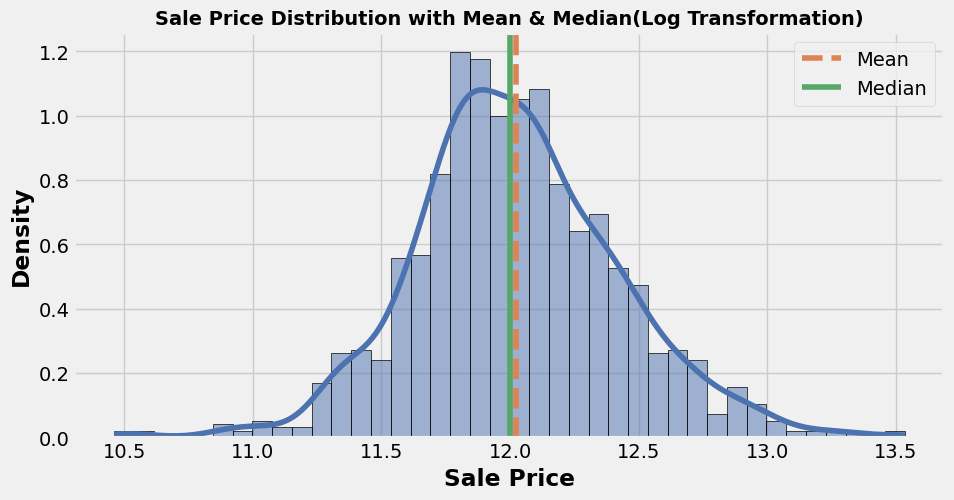

In [26]:
plt.style.use('fivethirtyeight')
plt.figure(figsize=(10, 5))

sns.histplot(df["SalePrice"],bins=40,kde=True,stat="density",edgecolor="black",color="#4C72B0")

plt.axvline(df["SalePrice"].mean(),linestyle="--",label="Mean",color="#DD8452")

plt.axvline(df["SalePrice"].median(),linestyle="-",label="Median",color="#55A868")
ax = plt.gca()

plt.title("Sale Price Distribution with Mean & Median(Log Transformation)", fontsize=14, fontweight="bold")
plt.xlabel("Sale Price",fontweight='semibold')
plt.ylabel("Density",fontweight='semibold')
plt.legend()

plt.show()

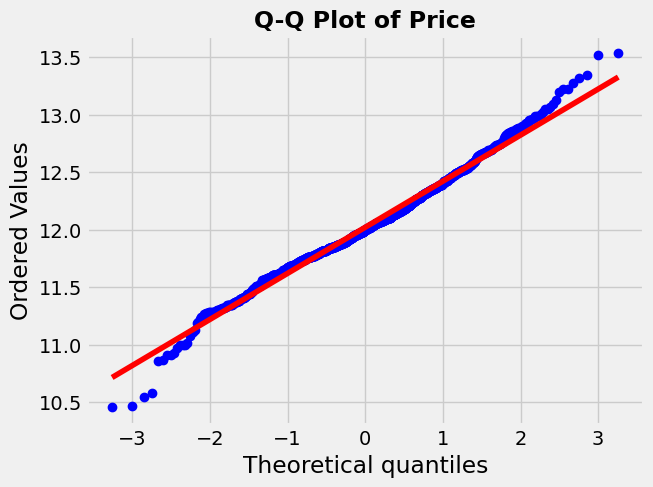

In [27]:
stats.probplot(df["SalePrice"], plot=plt)
plt.title("Q-Q Plot of Price",fontsize=17, fontweight="bold")
plt.show()

# Ordinal Columns and Nominal Columns

In [28]:
ordinal_cols = {
    "LotShape":        ["IR3", "IR2", "IR1", "Reg"],
    "LandSlope":       ["Sev", "Mod", "Gtl"],
    "LandContour":     ["Low", "HLS", "Bnk", "Lvl"],

    "ExterQual":       ["Po", "Fa", "TA", "Gd", "Ex"],
    "ExterCond":       ["Po", "Fa", "TA", "Gd", "Ex"],

    "BsmtQual":        ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtCond":        ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtExposure":    ["NA", "No", "Mn", "Av", "Gd"],
    "BsmtFinType1":    ["NA", "Unf", "LwQ", "BLQ", "Rec", "ALQ", "GLQ"],
    "BsmtFinType2":    ["NA", "Unf", "LwQ", "BLQ", "Rec", "ALQ", "GLQ"],

    "HeatingQC":       ["Po", "Fa", "TA", "Gd", "Ex"],
    "KitchenQual":     ["Po", "Fa", "TA", "Gd", "Ex"],

    "Functional":      ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],

    "FireplaceQu":     ["NA", "Po", "Fa", "TA", "Gd", "Ex"],

    "GarageFinish":    ["NA", "Unf", "RFn", "Fin"],
    "GarageQual":      ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageCond":      ["NA", "Po", "Fa", "TA", "Gd", "Ex"],

    "PavedDrive":      ["N", "P", "Y"],
    "Fence":           ["NA", "MnWw", "GdWo", "MnPrv", "GdPrv"],
}

nominal_cols = [
    "MSZoning","Alley","LotConfig","Neighborhood","Condition1",
    "BldgType","HouseStyle","RoofStyle","Exterior1st","Exterior2nd",
    "MasVnrType","Foundation","CentralAir","Electrical",
    "GarageType","SaleType","SaleCondition"
]

df["MSSubClass"] = df["MSSubClass"].astype(str)
nominal_cols.append("MSSubClass")

for col in ordinal_cols:
    df[col] = df[col].fillna("NA")


# Holdout Transformations

In [29]:
df_holdout["MasVnrArea"] = df_holdout["MasVnrArea"].fillna(0)
df_holdout[amenity_cols] = df_holdout[amenity_cols].fillna("NA")
df_holdout["GarageYrBlt"] = df_holdout["GarageYrBlt"].fillna(df_holdout["YearBuilt"])
df_holdout["LotFrontage"] = df_holdout["LotFrontage"].fillna(df_holdout["Neighborhood"].map(neighborhood_medians))
df_holdout["StreetIsGrvl"] = (df_holdout["Street"] == "Grvl").astype(int)
df_holdout["HeatingIsGasA"] = (df_holdout["Heating"] == "GasA").astype(int)
df_holdout["HouseAge"] = df_holdout["YrSold"] - df_holdout["YearBuilt"]
df_holdout['HouseRemodelAge'] = df_holdout['YrSold'] - df_holdout['YearRemodAdd']
df_holdout["IsRemodeled"] = (df_holdout["YearRemodAdd"] != df_holdout["YearBuilt"]).astype(int)
df_holdout["TotalLivingArea"] = df_holdout["GrLivArea"] + df_holdout["TotalBsmtSF"]
df_holdout['TotalBaths'] = df_holdout['BsmtFullBath'] + df_holdout['FullBath'] + 0.5 * (df_holdout['BsmtHalfBath'] + df_holdout['HalfBath']) 
df_holdout['TotalPorchSF'] = df_holdout['OpenPorchSF'] + df_holdout['3SsnPorch'] + df_holdout['EnclosedPorch'] + df_holdout['ScreenPorch'] + df_holdout['WoodDeckSF']
df_holdout["HasBasement"] = (df_holdout["TotalBsmtSF"] > 0).astype(int)
df_holdout["HasGarage"] = (df_holdout["GarageCars"] > 0).astype(int)
df_holdout["FinishedBasementRatioPrimary"] = (df_holdout["BsmtFinSF1"] / df_holdout["TotalBsmtSF"].replace(0, np.nan)).fillna(0)
df_holdout["FinishedBasementRatioTotal"] = ((df_holdout["BsmtFinSF1"] + df_holdout["BsmtFinSF2"]) / df_holdout["TotalBsmtSF"].replace(0, np.nan)).fillna(0)
df_holdout["HasSecondFloor"] = (df_holdout["2ndFlrSF"] > 0).astype(int)
df_holdout["MoSold_sin"] = np.sin(2 * np.pi * df_holdout["MoSold"] / 12)
df_holdout["MoSold_cos"] = np.cos(2 * np.pi * df_holdout["MoSold"] / 12)
porch_cols = [
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch"
]
df_holdout["HasPorch"] = (df_holdout[porch_cols].sum(axis=1) > 0).astype(int)
df_holdout["HasFireplace"] = (df_holdout["Fireplaces"] > 0).astype(int)
df_holdout["GarageAge"] = df_holdout["YrSold"] - df_holdout["GarageYrBlt"]
df_holdout["GarageAge"] = df_holdout["GarageAge"].clip(lower=0)
df_holdout["PremiumRoof"] = df_holdout["RoofMatl"].isin(["WdShngl", "WdShake"]).astype(int)
df_holdout["GasHeating"] = df_holdout["Heating"].isin(["GasA", "GasW"]).astype(int)
df_holdout["MSSubClass"] = df_holdout["MSSubClass"].astype(str)

for col in ordinal_cols:
    df_holdout[col] = df_holdout[col].fillna("NA")

cols_to_drop = ['Id','YrSold', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'BsmtFinSF1', 'BsmtFinSF2', 'GrLivArea', 
                'TotalBsmtSF','BsmtFullBath', 'FullBath', 'BsmtHalfBath', 'HalfBath', 'OpenPorchSF', '3SsnPorch', 'EnclosedPorch', 
                'ScreenPorch','WoodDeckSF',"MoSold","MiscVal","MiscFeature","GarageArea","PoolArea","PoolQC","GarageYrBlt","Street","Utilities","RoofMatl",
                "Condition2","Heating"]

df_holdout.drop(columns=cols_to_drop,inplace = True)

In [30]:
df_holdout["SalePrice"] = np.log1p(df_holdout["SalePrice"])

# One Hot Encoding and Ordinal Encoding

In [31]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]
X_holdout = df_holdout.drop("SalePrice", axis=1)
y_holdout = df_holdout["SalePrice"]
ordinal_features = list(ordinal_cols.keys())
ordinal_categories = [ordinal_cols[c] for c in ordinal_features]

In [32]:
ord_enc = OrdinalEncoder(
    categories=ordinal_categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)
ohe_enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        ("ord", ord_enc, ordinal_features),
        ("nom", ohe_enc, nominal_cols)
    ],
    remainder="passthrough"
)

pipe = Pipeline(
    steps=[("preprocess", preprocessor)]
)

# Processed Data Export

In [34]:
pipe.fit(X)
X_processed = pipe.transform(X)
X_holdout_processed = pipe.transform(X_holdout)

In [ ]:
joblib.dump(pipe, "../models/encoding_pipe.pkl")

In [35]:
feature_names = pipe.named_steps["preprocess"].get_feature_names_out()

In [36]:
pd.DataFrame(X_holdout_processed, columns=feature_names).to_parquet("../data/processed/holdout_X.parquet")
y_holdout.to_frame().to_parquet("../data/processed/holdout_y.parquet")

In [37]:
pd.DataFrame(X_processed, columns=feature_names).to_parquet("../data/processed/train_X_fe.parquet")
y.to_frame().to_parquet("../data/processed/train_y.parquet")